# Module 06b: Single-Cell Pathway Analysis (SCPA)

## Biological Question
Does pathway activity differ between SnC and Non-SnC cells, providing complementary evidence to ORA that SenePy captures senescence biology?

## Method
Single-Cell Pathway Analysis (SCPA) tests for coordinated expression changes across pathway gene sets, even when individual genes don't reach DEG significance.

## Comparison with Module 06a (ORA)
- ORA uses DEG lists and asks "are my significant genes enriched in pathways?"
- SCPA uses full expression matrix and asks "is pathway activity different between conditions?"
- SCPA can detect subtle coordinated shifts that ORA misses

## Databases
KEGG (KEGG_MEDICUS + KEGG_LEGACY) and Reactome — same as Module 06a for direct comparison.

## Cell Types
Microglia, Astrocyte, OPC (per cell type analysis)

## Comparison
SnC vs Non-SnC (all ages)

## Inputs
- Seurat object with senescence labels (from Module 04)
- MSigDB pathway gene sets

In [1]:
# %% Cell 1: Setup and Configuration (CORRECTED filename)
# ============================================================
# MODULE 06b: SCPA PATHWAY ACTIVITY ANALYSIS
# ============================================================

library(SCPA)
library(msigdbr)
library(Seurat)
library(qs)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)
library(scales)

# ------------------------------------------------------------
# Dataset Selection
# ------------------------------------------------------------
DATASET <- 'psychad_aging'  # Options: 'psychad_aging', 'psychad_ad', 'psychencode', 'mathys'

# ------------------------------------------------------------
# Dataset-Specific Configurations
# ------------------------------------------------------------
DATASET_CONFIG <- list(
  psychad_aging = list(
    study_type = 'aging',
    display_name = 'PsychAD Aging',
    seurat_file = 'psychad_aging_seurat.qs',
    cell_type_column = 'subclass'
  ),
  psychad_ad = list(
    study_type = 'disease',
    display_name = 'PsychAD AD',
    seurat_file = 'psychad_ad_seurat.qs',
    cell_type_column = 'subclass'
  ),
  psychencode = list(
    study_type = 'aging',
    display_name = 'PsychENCODE',
    seurat_file = 'psychencode_seurat.qs',
    cell_type_column = 'major_celltype'
  ),
  mathys = list(
    study_type = 'disease',
    display_name = 'Mathys',
    seurat_file = 'mathys_seurat.qs',
    cell_type_column = 'broad.cell.type'
  )
)

config <- DATASET_CONFIG[[DATASET]]
STUDY_TYPE <- config$study_type
DISPLAY_NAME <- config$display_name
SEURAT_FILE <- config$seurat_file
CELL_TYPE_COLUMN <- config$cell_type_column

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIR <- '/fs/scratch/PAS2598/senescence_analysis'

INPUT_DIR <- file.path(BASE_DIR, 'data', '04_subsetting', DATASET)
SEURAT_PATH <- file.path(INPUT_DIR, SEURAT_FILE)

RESULTS_DIR <- file.path(BASE_DIR, 'results', '06_pathway_enrichment', DATASET)
FIGURES_DIR <- file.path(BASE_DIR, 'figures', '06_pathway_enrichment', DATASET)

dir.create(RESULTS_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIGURES_DIR, recursive = TRUE, showWarnings = FALSE)

# ------------------------------------------------------------
# Analysis Parameters
# ------------------------------------------------------------
FDR_THRESHOLD <- 0.05
FC_THRESHOLD <- 5
CELL_TYPES <- c('Microglia') #, 'Astrocyte') #, 'OPC')
SENESCENCE_LABEL_COL <- 'senescence_label'

# ------------------------------------------------------------
# Verify Paths Exist
# ------------------------------------------------------------
cat("============================================================\n")
cat("MODULE 06b: SCPA PATHWAY ACTIVITY ANALYSIS\n")
cat("============================================================\n")
cat("\nDataset:", DISPLAY_NAME, "(", DATASET, ")\n")
cat("Study type:", STUDY_TYPE, "\n")
cat("\nPaths:\n")
cat("  Seurat: ", SEURAT_PATH, "\n")
cat("  Results:", RESULTS_DIR, "\n")
cat("  Figures:", FIGURES_DIR, "\n")

cat("\n------------------------------------------------------------\n")
cat("File checks:\n")
if (file.exists(SEURAT_PATH)) {
  cat("  ✓ Seurat file exists\n")
  cat("    Size:", round(file.size(SEURAT_PATH) / 1e9, 2), "GB\n")
} else {
  cat("  ✗ Seurat file NOT FOUND!\n")
}

cat("\nParameters:\n")
cat("  FDR threshold:", FDR_THRESHOLD, "\n")
cat("  FC threshold: ", FC_THRESHOLD, "\n")
cat("  Cell types:   ", paste(CELL_TYPES, collapse = ", "), "\n")

cat("\n============================================================\n")
cat("Setup complete\n")

This is version 1.6.2 of SCPA
For SCPA tutorials and latest version: https://jackbibby1.github.io/SCPA/
For the SCPA GitHub page: https://github.com/jackbibby1/SCPA
If you use SCPA, please cite: Bibby JA. et al. Cell Rep. 2022


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




MODULE 06b: SCPA PATHWAY ACTIVITY ANALYSIS

Dataset: PsychAD Aging ( psychad_aging )
Study type: aging 

Paths:
  Seurat:  /fs/scratch/PAS2598/senescence_analysis/data/04_subsetting/psychad_aging/psychad_aging_seurat.qs 
  Results: /fs/scratch/PAS2598/senescence_analysis/results/06_pathway_enrichment/psychad_aging 
  Figures: /fs/scratch/PAS2598/senescence_analysis/figures/06_pathway_enrichment/psychad_aging 

------------------------------------------------------------
File checks:
  ✓ Seurat file exists
    Size: 11.63 GB

Parameters:
  FDR threshold: 0.05 
  FC threshold:  5 
  Cell types:    Microglia 

Setup complete


In [2]:
# %% Cell 2: Load Pathway Gene Sets
# ============================================================

cat("Loading MSigDB collections...\n")

# Load each collection
reactome_data <- msigdbr(species = 'Homo sapiens', 
                         collection = 'C2', 
                         subcollection = 'CP:REACTOME')

kegg_medicus_data <- msigdbr(species = 'Homo sapiens', 
                             collection = 'C2', 
                             subcollection = 'CP:KEGG_MEDICUS')

kegg_legacy_data <- msigdbr(species = 'Homo sapiens', 
                            collection = 'C2', 
                            subcollection = 'CP:KEGG_LEGACY')

# Combine and format for SCPA
combined_data <- rbind(reactome_data, kegg_medicus_data, kegg_legacy_data)
pathways <- combined_data %>% format_pathways()

cat("✓ Loaded", length(pathways), "pathways\n")
cat("  Reactome:    ", length(unique(reactome_data$gs_name)), "\n")
cat("  KEGG MEDICUS:", length(unique(kegg_medicus_data$gs_name)), "\n")
cat("  KEGG LEGACY: ", length(unique(kegg_legacy_data$gs_name)), "\n")

Loading MSigDB collections...
✓ Loaded 2631 pathways
  Reactome:     1787 
  KEGG MEDICUS: 658 
  KEGG LEGACY:  186 


In [3]:
# %% Cell 3: Load Seurat Object
# ============================================================

cat("============================================================\n")
cat("LOADING SEURAT OBJECT\n")
cat("============================================================\n")

cat("\nLoading:", SEURAT_PATH, "\n")
cat("This may take a few minutes for an 11.6 GB file...\n\n")

seurat_obj <- qread(SEURAT_PATH)

cat("✓ Loaded successfully\n\n")

# ------------------------------------------------------------
# Basic info
# ------------------------------------------------------------
cat("------------------------------------------------------------\n")
cat("OBJECT SUMMARY\n")
cat("------------------------------------------------------------\n")
cat("Cells: ", ncol(seurat_obj), "\n")
cat("Genes: ", nrow(seurat_obj), "\n")
cat("Assays:", paste(Assays(seurat_obj), collapse = ", "), "\n")
cat("Default assay:", DefaultAssay(seurat_obj), "\n")

# ------------------------------------------------------------
# Check metadata columns
# ------------------------------------------------------------
cat("\n------------------------------------------------------------\n")
cat("METADATA COLUMNS\n")
cat("------------------------------------------------------------\n")
meta_cols <- colnames(seurat_obj@meta.data)
cat("Total columns:", length(meta_cols), "\n\n")

# Key columns we need
key_cols <- c(CELL_TYPE_COLUMN, SENESCENCE_LABEL_COL, 'senescence_score', 'is_senescent')
cat("Key columns check:\n")
for (col in key_cols) {
  if (col %in% meta_cols) {
    cat("  ✓", col, "\n")
  } else {
    cat("  ✗", col, "- NOT FOUND\n")
  }
}

# ------------------------------------------------------------
# Cell type distribution
# ------------------------------------------------------------
cat("\n------------------------------------------------------------\n")
cat("CELL TYPE DISTRIBUTION\n")
cat("------------------------------------------------------------\n")
ct_table <- table(seurat_obj@meta.data[[CELL_TYPE_COLUMN]])
ct_df <- as.data.frame(ct_table)
colnames(ct_df) <- c("CellType", "Count")
ct_df <- ct_df[order(-ct_df$Count), ]

for (i in 1:nrow(ct_df)) {
  marker <- ifelse(ct_df$CellType[i] %in% CELL_TYPES, "→", " ")
  cat(sprintf("  %s %-20s %s\n", marker, ct_df$CellType[i], format(ct_df$Count[i], big.mark = ",")))
}

# ------------------------------------------------------------
# Senescence label distribution
# ------------------------------------------------------------
cat("\n------------------------------------------------------------\n")
cat("SENESCENCE LABEL DISTRIBUTION\n")
cat("------------------------------------------------------------\n")
if (SENESCENCE_LABEL_COL %in% meta_cols) {
  sen_table <- table(seurat_obj@meta.data[[SENESCENCE_LABEL_COL]])
  for (label in names(sen_table)) {
    pct <- round(100 * sen_table[label] / sum(sen_table), 1)
    cat(sprintf("  %-10s %s (%s%%)\n", label, format(sen_table[label], big.mark = ","), pct))
  }
} else {
  cat("  Senescence label column not found!\n")
}

# ------------------------------------------------------------
# Senescence by cell type (for our target cell types)
# ------------------------------------------------------------
cat("\n------------------------------------------------------------\n")
cat("SENESCENCE BY CELL TYPE (target cell types)\n")
cat("------------------------------------------------------------\n")
for (ct in CELL_TYPES) {
  ct_cells <- seurat_obj@meta.data[[CELL_TYPE_COLUMN]] == ct
  if (sum(ct_cells) > 0) {
    sen_in_ct <- table(seurat_obj@meta.data[ct_cells, SENESCENCE_LABEL_COL])
    snc_count <- ifelse("SnC" %in% names(sen_in_ct), sen_in_ct["SnC"], 0)
    non_count <- ifelse("Non-SnC" %in% names(sen_in_ct), sen_in_ct["Non-SnC"], 0)
    total <- sum(sen_in_ct)
    pct_snc <- round(100 * snc_count / total, 1)
    cat(sprintf("  %-12s SnC: %6s (%5s%%)  Non-SnC: %s\n", 
                ct, format(snc_count, big.mark = ","), pct_snc, format(non_count, big.mark = ",")))
  } else {
    cat(sprintf("  %-12s Not found in data\n", ct))
  }
}

cat("\n============================================================\n")
cat("Seurat object loaded and inspected\n")

LOADING SEURAT OBJECT

Loading: /fs/scratch/PAS2598/senescence_analysis/data/04_subsetting/psychad_aging/psychad_aging_seurat.qs 
This may take a few minutes for an 11.6 GB file...

✓ Loaded successfully

------------------------------------------------------------
OBJECT SUMMARY
------------------------------------------------------------
Cells:  122192 
Genes:  34890 
Assays: RNA 
Default assay: RNA 

------------------------------------------------------------
METADATA COLUMNS
------------------------------------------------------------
Total columns: 85 

Key columns check:
  ✓ subclass 
  ✓ senescence_label 
  ✓ senescence_score 
  ✓ is_senescent 

------------------------------------------------------------
CELL TYPE DISTRIBUTION
------------------------------------------------------------
    Astrocyte            63,658
    OPC                  36,059
  → Microglia            22,475

------------------------------------------------------------
SENESCENCE LABEL DISTRIBUTION
-----

In [4]:
# %% Cell 4: Run SCPA - SnC vs Non-SnC per Cell Type
# ============================================================

cat("Running SCPA: SnC vs Non-SnC\n")
cat("============================================================\n\n")

scpa_results <- list()

for (ct in CELL_TYPES) {
  cat("Processing", ct, "...\n")
  
  # Subset to cell type
  ct_obj <- subset(seurat_obj, cells = which(seurat_obj@meta.data[[CELL_TYPE_COLUMN]] == ct))
  
  # Extract SnC and Non-SnC populations
  snc_cells <- seurat_extract(ct_obj, 
                               meta1 = SENESCENCE_LABEL_COL, 
                               value_meta1 = "SnC")
  
  nonsnc_cells <- seurat_extract(ct_obj, 
                                  meta1 = SENESCENCE_LABEL_COL, 
                                  value_meta1 = "Non-SnC")
  
  # ncol = cells, nrow = genes
  cat("  SnC:", ncol(snc_cells), "cells | Non-SnC:", ncol(nonsnc_cells), "cells\n")
  
  # Run SCPA (SnC vs Non-SnC)
  scpa_out <- compare_pathways(samples = list(snc_cells, nonsnc_cells),
                                pathways = pathways)
  
  scpa_out$cell_type <- ct
  scpa_results[[ct]] <- scpa_out
  
  # Quick summary
  n_sig <- sum(scpa_out$adjPval < FDR_THRESHOLD, na.rm = TRUE)
  cat("  Significant pathways (FDR <", FDR_THRESHOLD, "):", n_sig, "\n\n")
}

# Combine all results
scpa_combined <- bind_rows(scpa_results)

cat("✓ SCPA complete\n")

Running SCPA: SnC vs Non-SnC

Processing Microglia ...


Extracting cells where senescence_label == SnC

Extracting data from the RNA assay

Extracting cells where senescence_label == Non-SnC

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 5.3 GiB”
Extracting data from the RNA assay



  SnC: 2233 cells | Non-SnC: 20242 cells


Using single core processing. Specify 'parallel = TRUE' and `cores = x` arguments for parallel processing


Cell numbers in population 1 = 2233

Cell numbers in population 2 = 20242

- If greater than 500 cells, these populations will be downsampled


Excluding 1138 pathway(s) based on min/max genes parameter: KEGG_ASCORBATE_AND_ALDARATE_METABOLISM, KEGG_CIRCADIAN_RHYTHM_MAMMAL, KEGG_FOLATE_BIOSYNTHESIS, KEGG_GLYCOSPHINGOLIPID_BIOSYNTHESIS_GANGLIO_SERIES, KEGG_GLYCOSPHINGOLIPID_BIOSYNTHESIS_GLOBO_SERIES...


Calculating pathway fold changes...


Performing a two-sample analysis with SCPA...



  |==================================================| 100%
  Significant pathways (FDR < 0.05 ): 1451 

✓ SCPA complete


In [5]:
# %% Cell 5: Save Results
# ============================================================

cat("Saving SCPA results...\n")

# Save combined results
write.csv(scpa_combined, 
          file.path(RESULTS_DIR, paste0(DATASET, "_scpa_snc_vs_nonsnc_all.csv")),
          row.names = FALSE)

# Save per cell type
for (ct in CELL_TYPES) {
  ct_results <- scpa_results[[ct]]
  write.csv(ct_results,
            file.path(RESULTS_DIR, paste0(DATASET, "_scpa_snc_vs_nonsnc_", tolower(ct), ".csv")),
            row.names = FALSE)
  cat("  Saved:", ct, "-", nrow(ct_results), "pathways\n")
}

cat("\n✓ Results saved to:", RESULTS_DIR, "\n")

Saving SCPA results...
  Saved: Microglia - 1493 pathways

✓ Results saved to: /fs/scratch/PAS2598/senescence_analysis/results/06_pathway_enrichment/psychad_aging 



Generating plot for Microglia ...
  Saved: Microglia figure

✓ All figures saved to: /fs/scratch/PAS2598/senescence_analysis/figures/06_pathway_enrichment/psychad_aging 


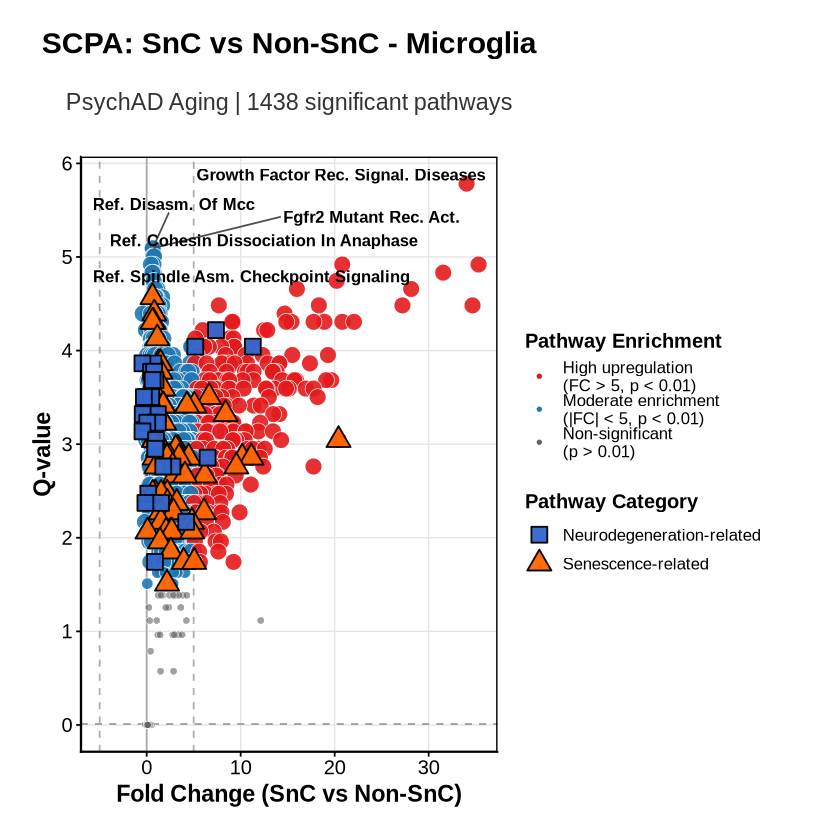

In [6]:
# %% Cell 6: Visualization - Per Cell Type
# ============================================================

library(stringr)

font_family <- "sans"

clean_pathway_name <- function(pathway) {
  cleaned <- gsub("^(REACTOME_|KEGG_MEDICUS_|KEGG_LEGACY_|KEGG_)", "", pathway)
  cleaned <- gsub("_", " ", cleaned)
  cleaned <- str_to_title(cleaned)
  # Abbreviations
  cleaned <- gsub("Signaling Pathway", "Signaling", cleaned)
  cleaned <- gsub("Regulation Of", "Reg.", cleaned)
  cleaned <- gsub("Associated", "Assoc.", cleaned)
  cleaned <- gsub("Transcription", "Txn", cleaned)
  cleaned <- gsub("Through", "via", cleaned)
  cleaned <- gsub("Mediated", "Med.", cleaned)
  cleaned <- gsub("Formation Of", "", cleaned)
  cleaned <- gsub("Diseases Of Signal Transduction By Growth Factor Receptors And Second Messengers", 
                  "Growth Factor Rec. Signal. Diseases", cleaned)
  cleaned <- gsub("Senescence Assoc. Heterochromatin Foci Sahf", "SAHF Formation", cleaned)
  cleaned <- gsub("Oxidative Stress Induced Senescence", "Oxidative Stress Senescence", cleaned)
  cleaned <- gsub("Dna Damage Telomere Stress Induced Senescence", "DNA Damage Senescence", cleaned)
  cleaned <- gsub("Senescence Assoc. Secretory Phenotype Sasp", "SASP", cleaned)
  cleaned <- gsub("Activation", "Act.", cleaned)
  cleaned <- gsub("Inactivation", "Inact.", cleaned)
  cleaned <- gsub("Complex", "Cmplx", cleaned)
  cleaned <- gsub("Receptor", "Rec.", cleaned)
  cleaned <- gsub("Metabolism", "Metab.", cleaned)
  cleaned <- gsub("Biosynthesis", "Biosynth.", cleaned)
  cleaned <- gsub("Development", "Dev.", cleaned)
  cleaned <- gsub("Differentiation", "Diff.", cleaned)
  cleaned <- gsub("Proliferation", "Prolif.", cleaned)
  cleaned <- gsub("Degradation", "Degrad.", cleaned)
  cleaned <- gsub("Processing", "Process.", cleaned)
  cleaned <- gsub("Assembly", "Asm.", cleaned)
  cleaned <- gsub("Disassembly", "Disasm.", cleaned)
  cleaned <- gsub("Reference", "Ref.", cleaned)
  return(cleaned)
}

pub_colors <- c(
  'High upregulation\n(FC > 5, p < 0.01)' = '#e31a1c',
  'Moderate enrichment\n(|FC| < 5, p < 0.01)' = '#1f78b4',
  'High downregulation\n(FC < -5, p < 0.01)' = '#33a02c',
  'Non-significant\n(p > 0.01)' = '#636363'
)

pub_theme <- theme_classic(base_family = font_family) +
  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5, margin = margin(b = 20)),
    plot.subtitle = element_text(size = 14, hjust = 0.5, margin = margin(b = 25), color = "grey20"),
    axis.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12, color = "black"),
    legend.position = "right",
    legend.title = element_text(size = 12, face = "bold"),
    legend.text = element_text(size = 10),
    legend.spacing.y = unit(0.3, "cm"),
    panel.grid.major = element_line(color = "grey90", linewidth = 0.4),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 0.8),
    plot.margin = margin(t = 20, r = 25, b = 20, l = 20)
  )

senescence_keywords <- c("SENESC", "AGING", "AGE", "P53", "P21", "P16", "TELOMERE", 
                         "DNA_DAMAGE", "OXIDATIVE_STRESS", "APOPTOSIS", "AUTOPHAGY")
neurodegeneration_keywords <- c("NEURO", "ALZHEIMER", "PARKINSON", "AMYLOID", "TAU",
                                "SYNAPTIC", "AXONAL", "DOPAMINE", "GLUTAMATE")

senescence_pattern <- paste(senescence_keywords, collapse = "|")
neurodegeneration_pattern <- paste(neurodegeneration_keywords, collapse = "|")

for (ct in CELL_TYPES) {
  
  cat("\nGenerating plot for", ct, "...\n")
  
  scpa_out <- scpa_results[[ct]] %>%
    filter(!is.na(Pathway) & !is.na(FC) & !is.na(adjPval) & !is.na(qval))
  
  scpa_out <- scpa_out %>%
    mutate(
      clean_label = clean_pathway_name(Pathway),
      significance_category = case_when(
        adjPval > 0.01 ~ 'Non-significant\n(p > 0.01)',
        FC > 5 & adjPval < 0.01 ~ 'High upregulation\n(FC > 5, p < 0.01)',
        FC < -5 & adjPval < 0.01 ~ 'High downregulation\n(FC < -5, p < 0.01)',
        TRUE ~ 'Moderate enrichment\n(|FC| < 5, p < 0.01)'
      ),
      point_size = case_when(
        adjPval > 0.01 ~ 1.8,
        adjPval <= 0.001 ~ 4.5,
        TRUE ~ 3.0
      ),
      point_alpha = ifelse(adjPval > 0.01, 0.6, 0.9),
      # Add pathway category for shape legend
      pathway_category = case_when(
        grepl(senescence_pattern, Pathway, ignore.case = TRUE) ~ "Senescence-related",
        grepl(neurodegeneration_pattern, Pathway, ignore.case = TRUE) ~ "Neurodegeneration-related",
        TRUE ~ "Other"
      )
    )
  
  senescence_paths <- scpa_out %>% 
    filter(pathway_category == "Senescence-related" & adjPval < 0.01)
  
  neurodegeneration_paths <- scpa_out %>% 
    filter(pathway_category == "Neurodegeneration-related" & adjPval < 0.01)
  
  # Top 5 pathways only
  top_paths <- scpa_out %>%
    filter(adjPval < 0.01) %>%
    arrange(adjPval) %>%
    slice_head(n = 5)
  
  p <- ggplot(scpa_out, aes(x = FC, y = qval)) +
    geom_vline(xintercept = c(-5, 0, 5), linetype = c("dashed", "solid", "dashed"), 
               color = "grey60", linewidth = 0.5, alpha = 0.8) +
    geom_hline(yintercept = 0.01, linetype = "dashed", color = "grey60", linewidth = 0.5) +
    geom_point(aes(fill = significance_category, size = point_size, alpha = point_alpha), 
               shape = 21, stroke = 0.3, color = "white") +
    scale_size_identity() +
    scale_alpha_identity() +
    scale_fill_manual(name = "Pathway Enrichment", values = pub_colors) +
    # Senescence paths with shape mapped for legend
    geom_point(data = senescence_paths, 
               aes(shape = "Senescence-related"),
               size = 4.5, fill = "#ff6600", stroke = 0.8, alpha = 0.95) +
    # Neurodegeneration paths with shape mapped for legend
    geom_point(data = neurodegeneration_paths, 
               aes(shape = "Neurodegeneration-related"),
               size = 4.5, fill = "#3366cc", stroke = 0.8, alpha = 0.95) +
    scale_shape_manual(name = "Pathway Category",
                       values = c("Senescence-related" = 24, 
                                  "Neurodegeneration-related" = 22),
                       guide = guide_legend(
                         override.aes = list(
                           fill = c("#ff6600", "#3366cc"),
                           size = 4.5,
                           stroke = 0.8,
                           alpha = 0.95
                         )
                       )) +
    geom_text_repel(data = top_paths, aes(label = clean_label),
                    size = 3.5, fontface = "bold", max.overlaps = 15,
                    box.padding = 0.5, segment.color = "grey30") +
    scale_x_continuous(name = "Fold Change (SnC vs Non-SnC)", breaks = scales::pretty_breaks(n = 6)) +
    scale_y_continuous(name = "Q-value", breaks = scales::pretty_breaks(n = 6)) +
    ggtitle(paste0("SCPA: SnC vs Non-SnC - ", ct),
            subtitle = paste0(DISPLAY_NAME, " | ", sum(scpa_out$adjPval < 0.01), " significant pathways")) +
    pub_theme +
    guides(fill = guide_legend(order = 1),
           shape = guide_legend(order = 2))
  
  print(p)
  
  ggsave(file.path(FIGURES_DIR, paste0(DATASET, "_scpa_", tolower(ct), ".pdf")),
         plot = p, width = 12, height = 9, device = cairo_pdf)
  ggsave(file.path(FIGURES_DIR, paste0(DATASET, "_scpa_", tolower(ct), ".png")),
         plot = p, width = 12, height = 9, dpi = 300)
  
  cat("  Saved:", ct, "figure\n")
}

cat("\n✓ All figures saved to:", FIGURES_DIR, "\n")

In [7]:
# %% Cell 7: Explore Results & Save Tables
# ============================================================

cat("Processing SCPA results...\n\n")

# Combine all results
scpa_combined <- bind_rows(scpa_results)

# ============================================================
# Part 1: ALL SIGNIFICANT PATHWAYS
# ============================================================

cat("------------------------------------------------------------\n")
cat("ALL SIGNIFICANT PATHWAYS\n")
cat("------------------------------------------------------------\n")

all_sig <- scpa_combined %>%
  filter(adjPval < FDR_THRESHOLD)

cat("\nTotal significant pathways (FDR <", FDR_THRESHOLD, "):", nrow(all_sig), "\n")
cat("By cell type:\n")
print(table(all_sig$cell_type))

# Wide format - all significant
all_wide <- all_sig %>%
  mutate(clean_label = clean_pathway_name(Pathway)) %>%
  select(Pathway = clean_label, FC, cell_type) %>%
  group_by(Pathway, cell_type) %>%
  summarise(FC = mean(FC, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = cell_type, values_from = FC, names_prefix = "FC_")

cat("\nAll significant pathways (wide format preview):\n")
print(as.data.frame(all_wide %>% slice_head(n = 15)))

# ============================================================
# Part 2: TOP PATHWAYS PER CELL TYPE
# ============================================================

cat("\n------------------------------------------------------------\n")
cat("TOP 10 PATHWAYS PER CELL TYPE (by qval)\n")
cat("------------------------------------------------------------\n")

top_summary <- list()

for (ct in CELL_TYPES) {
  top_summary[[ct]] <- scpa_results[[ct]] %>%
    mutate(clean_label = clean_pathway_name(Pathway)) %>%
    arrange(desc(qval)) %>%
    slice_head(n = 10) %>%
    select(Pathway = clean_label, FC, qval, adjPval) %>%
    mutate(cell_type = ct)
  
  cat("\n", ct, ":\n")
  print(as.data.frame(top_summary[[ct]] %>% select(-cell_type)))
}

top_all <- bind_rows(top_summary)

# ============================================================
# Part 3: CHECK FOR SENESCENCE-RELATED PATHWAYS
# ============================================================

cat("\n------------------------------------------------------------\n")
cat("SENESCENCE-RELATED PATHWAYS CHECK\n")
cat("------------------------------------------------------------\n")

senescence_pattern <- "SENESC|AGING|P53|P21|P16|TELOMERE|DNA_DAMAGE|OXIDATIVE_STRESS|APOPTOSIS|AUTOPHAGY|SASP"

# Check in ALL results (not just significant)
sen_all <- scpa_combined %>%
  filter(grepl(senescence_pattern, Pathway, ignore.case = TRUE)) %>%
  mutate(clean_label = clean_pathway_name(Pathway))

cat("\nSenescence-related pathways in dataset:", n_distinct(sen_all$Pathway), "unique pathways\n")
cat("Total entries (across cell types):", nrow(sen_all), "\n")

# Check how many are significant
sen_sig <- sen_all %>% filter(adjPval < FDR_THRESHOLD)
cat("Significant (FDR <", FDR_THRESHOLD, "):", nrow(sen_sig), "\n")

cat("\nBy cell type:\n")
print(table(sen_sig$cell_type))

# Show senescence pathways with their stats
sen_summary <- sen_all %>%
  select(Pathway = clean_label, FC, qval, adjPval, cell_type) %>%
  arrange(cell_type, desc(qval))

cat("\nSenescence pathway details:\n")
print(as.data.frame(sen_summary))

# Wide format for senescence pathways
sen_wide <- sen_all %>%
  select(Pathway = clean_label, FC, cell_type) %>%
  group_by(Pathway, cell_type) %>%
  summarise(FC = mean(FC, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = cell_type, values_from = FC, names_prefix = "FC_")

cat("\nSenescence pathways across cell types (FC values):\n")
print(as.data.frame(sen_wide))

# ============================================================
# Part 4: SUMMARY STATISTICS
# ============================================================

cat("\n------------------------------------------------------------\n")
cat("SUMMARY STATISTICS\n")
cat("------------------------------------------------------------\n")

for (ct in CELL_TYPES) {
  res <- scpa_results[[ct]]
  n_total <- nrow(res)
  n_sig <- sum(res$adjPval < 0.05)
  n_sig_01 <- sum(res$adjPval < 0.01)
  n_high_fc <- sum(res$FC > 5 & res$adjPval < 0.01)
  n_sen <- sum(grepl(senescence_pattern, res$Pathway, ignore.case = TRUE))
  n_sen_sig <- sum(grepl(senescence_pattern, res$Pathway, ignore.case = TRUE) & res$adjPval < 0.05)
  
  cat("\n", ct, ":\n")
  cat("  Total pathways tested:", n_total, "\n")
  cat("  Significant (p < 0.05):", n_sig, sprintf("(%.1f%%)\n", 100*n_sig/n_total))
  cat("  Significant (p < 0.01):", n_sig_01, sprintf("(%.1f%%)\n", 100*n_sig_01/n_total))
  cat("  High FC (>5, p<0.01):", n_high_fc, "\n")
  cat("  Senescence-related (total):", n_sen, "\n")
  cat("  Senescence-related (p<0.05):", n_sen_sig, "\n")
}

# ============================================================
# Part 5: SAVE ALL FILES
# ============================================================

cat("\n------------------------------------------------------------\n")
cat("SAVING FILES\n")
cat("------------------------------------------------------------\n")

# Combined results
write.csv(scpa_combined, 
          file.path(RESULTS_DIR, paste0(DATASET, "_scpa_snc_vs_nonsnc_all.csv")),
          row.names = FALSE)
cat("✓ Combined results:", nrow(scpa_combined), "rows\n")

# Per cell type
for (ct in CELL_TYPES) {
  write.csv(scpa_results[[ct]],
            file.path(RESULTS_DIR, paste0(DATASET, "_scpa_snc_vs_nonsnc_", tolower(ct), ".csv")),
            row.names = FALSE)
}
cat("✓ Per cell type results saved\n")

# All significant wide
write.csv(all_wide,
          file.path(RESULTS_DIR, paste0(DATASET, "_scpa_all_significant_wide.csv")),
          row.names = FALSE)
cat("✓ All significant pathways (wide):", nrow(all_wide), "pathways\n")

# Top 10 summary
write.csv(top_all,
          file.path(RESULTS_DIR, paste0(DATASET, "_scpa_top10_per_celltype.csv")),
          row.names = FALSE)
cat("✓ Top 10 per cell type saved\n")

# Senescence pathways
write.csv(sen_summary,
          file.path(RESULTS_DIR, paste0(DATASET, "_scpa_senescence_pathways.csv")),
          row.names = FALSE)
write.csv(sen_wide,
          file.path(RESULTS_DIR, paste0(DATASET, "_scpa_senescence_pathways_wide.csv")),
          row.names = FALSE)
cat("✓ Senescence pathway tables saved\n")

cat("\n------------------------------------------------------------\n")
cat("Files saved to:", RESULTS_DIR, "\n")
cat("------------------------------------------------------------\n")

Processing SCPA results...

------------------------------------------------------------
ALL SIGNIFICANT PATHWAYS
------------------------------------------------------------

Total significant pathways (FDR < 0.05 ): 1451 
By cell type:

Microglia 
     1451 

All significant pathways (wide format preview):
                                                Pathway FC_Microglia
1                          Atp By Chemiosmotic Coupling    0.5253403
2                          Fibrin Clot Clotting Cascade    0.5044595
3                              Incision Cmplx In Gg Ner    2.7197674
4   Neuronal Progenitor And Neuronal Baf Npbaf And Nbaf    1.7623092
5                                     Paraxial Mesoderm    3.2971843
6                           Rna Pol Ii Elongation Cmplx    3.0251342
7                                        SAHF Formation    1.1280150
8                             Tc Ner Pre Incision Cmplx    2.6745230
9            The Beta Catenin Tcf Transactivating Cmplx    3.2956110



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Plotting 30 pathways

✓ Heatmap saved to: /fs/scratch/PAS2598/senescence_analysis/figures/06_pathway_enrichment/psychad_aging 


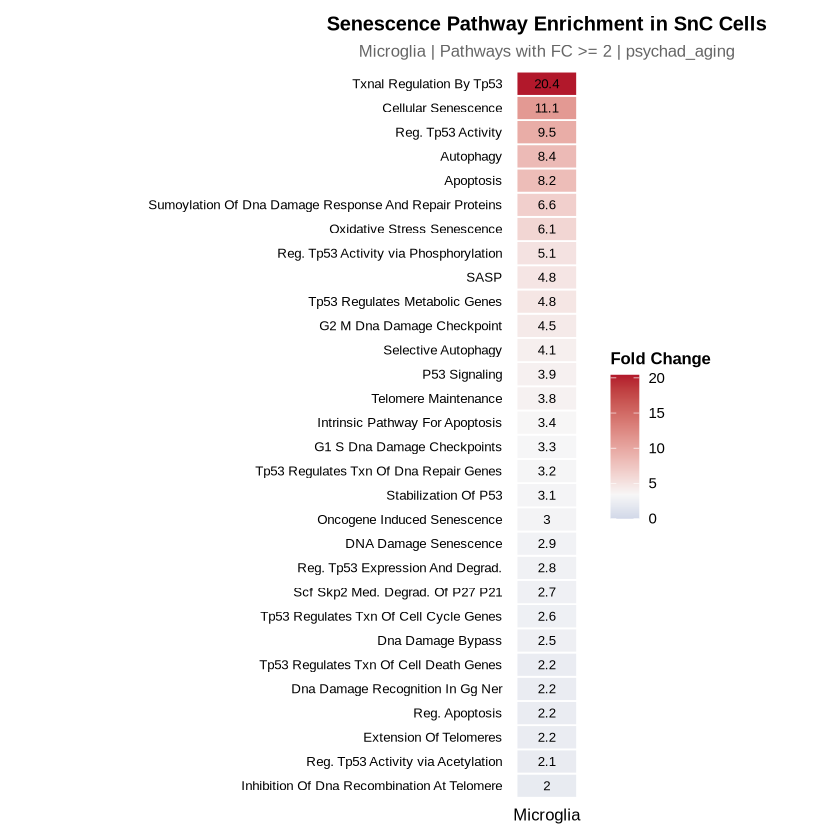

In [1]:
# %% Cell 8: Publication Heatmap (ggplot2) - Single Cell Type
# ============================================================

library(ggplot2)
library(dplyr)
library(tidyr)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATASET <- 'psychad_aging'
BASE_DIR <- '/fs/scratch/PAS2598/senescence_analysis'
RESULTS_DIR <- file.path(BASE_DIR, 'results', '06_pathway_enrichment', DATASET)
FIGURES_DIR <- file.path(BASE_DIR, 'figures', '06_pathway_enrichment', DATASET)

# ------------------------------------------------------------
# Load and filter data
# ------------------------------------------------------------

sen_wide <- read.csv(file.path(RESULTS_DIR, paste0(DATASET, "_scpa_senescence_pathways_wide.csv")))

# Extract Microglia only
heatmap_df <- sen_wide %>%
  select(Pathway, FC = FC_Microglia) %>%
  filter(!is.na(FC)) %>%
  filter(FC >= 2) %>%
  arrange(FC)  # Ascending for coord_flip display

cat("Plotting", nrow(heatmap_df), "pathways\n")

# Set factor levels for ordering
heatmap_df$Pathway <- factor(heatmap_df$Pathway, levels = heatmap_df$Pathway)
heatmap_df$CellType <- "Microglia"

# ------------------------------------------------------------
# Publication theme
# ------------------------------------------------------------

theme_heatmap <- theme_minimal() +
  theme(
    plot.title = element_text(size = 12, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 10, hjust = 0.5, color = "grey40"),
    axis.title = element_blank(),
    axis.text.x = element_text(size = 10, color = "black"),
    axis.text.y = element_text(size = 8, color = "black"),
    axis.ticks = element_blank(),
    panel.grid = element_blank(),
    legend.position = "right",
    legend.title = element_text(size = 10, face = "bold"),
    legend.text = element_text(size = 9),
    plot.margin = margin(10, 10, 10, 10)
  )

# ------------------------------------------------------------
# Create heatmap
# ------------------------------------------------------------

p <- ggplot(heatmap_df, aes(x = CellType, y = Pathway, fill = FC)) +
  geom_tile(color = "white", linewidth = 0.5) +
  geom_text(aes(label = round(FC, 1)), size = 2.8, color = "black") +
  scale_fill_gradient2(
    low = "#2166AC",
    mid = "#F7F7F7", 
    high = "#B2182B",
    midpoint = median(heatmap_df$FC),
    name = "Fold Change",
    limits = c(0, max(heatmap_df$FC)),
    breaks = seq(0, ceiling(max(heatmap_df$FC)), by = 5)
  ) +
  labs(
    title = "Senescence Pathway Enrichment in SnC Cells",
    subtitle = paste0("Microglia | Pathways with FC >= 2 | ", DATASET)
  ) +
  theme_heatmap +
  coord_fixed(ratio = 0.4)

print(p)

# Save
fig_height <- max(4, nrow(heatmap_df) * 0.3 + 2)
ggsave(file.path(FIGURES_DIR, paste0(DATASET, "_scpa_senescence_heatmap_microglia.pdf")),
       plot = p, width = 4, height = fig_height, device = cairo_pdf)
ggsave(file.path(FIGURES_DIR, paste0(DATASET, "_scpa_senescence_heatmap_microglia.png")),
       plot = p, width = 4, height = fig_height, dpi = 300)

cat("\n✓ Heatmap saved to:", FIGURES_DIR, "\n")

Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements a

Plotting 30 pathways
FC range: 2 - 20.4 


agg_record_2075828721 
                    2

agg_record_2075828721 
                    2


✓ ComplexHeatmap saved to: /fs/scratch/PAS2598/senescence_analysis/figures/06_pathway_enrichment/psychad_aging 


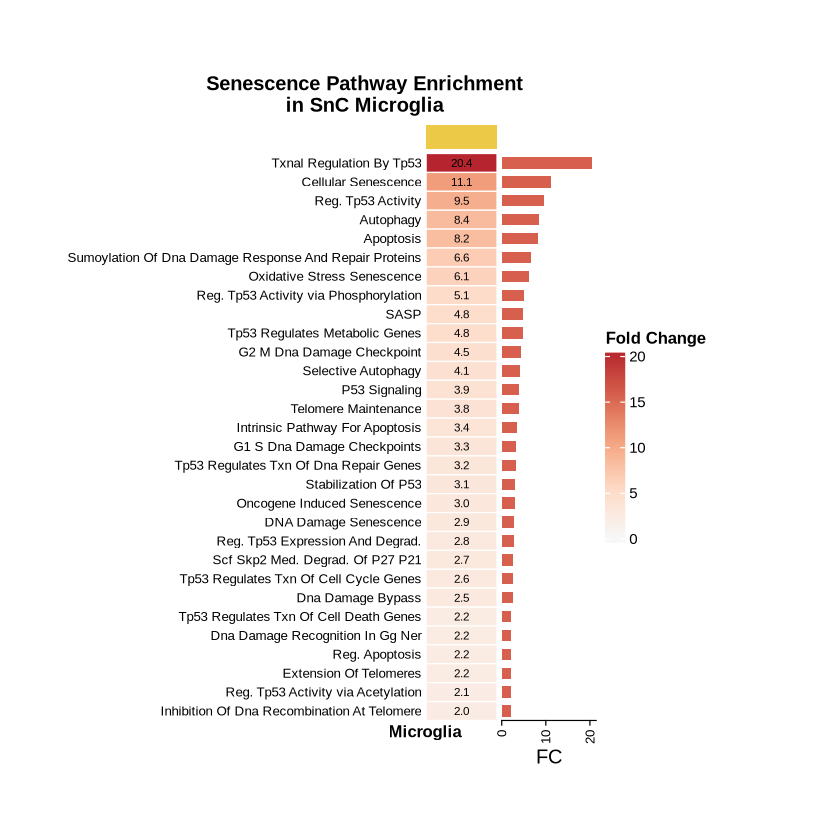

In [2]:
# %% Cell 8b: Publication Heatmap (ComplexHeatmap) - Single Cell Type
# ============================================================
# RUN IN: scanalysis conda environment
# conda activate scanalysis
# ============================================================

library(ComplexHeatmap)
library(circlize)
library(dplyr)
library(tidyr)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATASET <- 'psychad_aging'
BASE_DIR <- '/fs/scratch/PAS2598/senescence_analysis'
RESULTS_DIR <- file.path(BASE_DIR, 'results', '06_pathway_enrichment', DATASET)
FIGURES_DIR <- file.path(BASE_DIR, 'figures', '06_pathway_enrichment', DATASET)

# ------------------------------------------------------------
# Load and filter data
# ------------------------------------------------------------

sen_wide <- read.csv(file.path(RESULTS_DIR, paste0(DATASET, "_scpa_senescence_pathways_wide.csv")))

# Extract Microglia only - keep as matrix with 1 column
heatmap_mat <- as.matrix(sen_wide[, "FC_Microglia", drop = FALSE])
rownames(heatmap_mat) <- sen_wide$Pathway
colnames(heatmap_mat) <- "Microglia"

# Remove NA
heatmap_mat <- heatmap_mat[!is.na(heatmap_mat[, 1]), , drop = FALSE]

# Filter to FC >= 2
heatmap_filtered <- heatmap_mat[heatmap_mat[, 1] >= 2, , drop = FALSE]

# Order by FC (descending - highest at top)
row_order <- order(heatmap_filtered[, 1], decreasing = TRUE)
heatmap_filtered <- heatmap_filtered[row_order, , drop = FALSE]

cat("Plotting", nrow(heatmap_filtered), "pathways\n")
cat("FC range:", round(min(heatmap_filtered), 1), "-", round(max(heatmap_filtered), 1), "\n")

# ------------------------------------------------------------
# Color scale
# ------------------------------------------------------------

max_fc <- ceiling(max(heatmap_filtered))
col_fun <- colorRamp2(
  breaks = seq(0, max_fc, length.out = 5),
  colors = c("#F7F7F7", "#FDDBC7", "#F4A582", "#D6604D", "#B2182B")
)

# ------------------------------------------------------------
# Row annotation - FC bar
# ------------------------------------------------------------

row_fc <- heatmap_filtered[, 1]

row_ha <- rowAnnotation(
  "FC" = anno_barplot(
    row_fc,
    width = unit(2, "cm"),
    gp = gpar(fill = "#D6604D", col = NA),
    border = FALSE
  ),
  annotation_name_rot = 0
)

# ------------------------------------------------------------
# Column annotation - cell type color
# ------------------------------------------------------------

col_ha <- HeatmapAnnotation(
  "Cell Type" = "Microglia",
  col = list("Cell Type" = c("Microglia" = "#EDC948")),
  show_legend = FALSE,
  show_annotation_name = FALSE
)

# ------------------------------------------------------------
# Create heatmap
# ------------------------------------------------------------

ht <- Heatmap(
  heatmap_filtered,
  name = "FC",
  col = col_fun,
  
  # Clustering
 cluster_rows = FALSE,
  cluster_columns = FALSE,
  
  # Row settings
  row_names_side = "left",
  row_names_gp = gpar(fontsize = 8),
  row_title = NULL,
  
  # Column settings
  column_names_side = "bottom",
  column_names_rot = 0,
  column_names_gp = gpar(fontsize = 10, fontface = "bold"),
  column_title = NULL,
  
  # Cell settings
  rect_gp = gpar(col = "white", lwd = 1),
  
  # Add FC values in cells
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.text(sprintf("%.1f", heatmap_filtered[i, j]), 
              x, y, 
              gp = gpar(fontsize = 7, col = "black"))
  },
  
  # Annotations
  top_annotation = col_ha,
  right_annotation = row_ha,
  
  # Legend
  heatmap_legend_param = list(
    title = "Fold Change",
    title_gp = gpar(fontsize = 10, fontface = "bold"),
    labels_gp = gpar(fontsize = 9),
    legend_height = unit(4, "cm"),
    at = seq(0, max_fc, by = 5)
  ),
  
  # Size - narrower for single column
  width = unit(1.5, "cm"),
  height = unit(nrow(heatmap_filtered) * 0.4, "cm")
)

# ------------------------------------------------------------
# Draw with title
# ------------------------------------------------------------

draw(ht,
     column_title = "Senescence Pathway Enrichment\nin SnC Microglia",
     column_title_gp = gpar(fontsize = 12, fontface = "bold"),
     padding = unit(c(10, 10, 10, 10), "mm"))

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

fig_height <- max(5, nrow(heatmap_filtered) * 0.35 + 2)

pdf(file.path(FIGURES_DIR, paste0(DATASET, "_scpa_senescence_heatmap_microglia_complex.pdf")),
    width = 6, height = fig_height)
draw(ht,
     column_title = "Senescence Pathway Enrichment\nin SnC Microglia",
     column_title_gp = gpar(fontsize = 12, fontface = "bold"),
     padding = unit(c(10, 10, 10, 10), "mm"))
dev.off()

png(file.path(FIGURES_DIR, paste0(DATASET, "_scpa_senescence_heatmap_microglia_complex.png")),
    width = 6, height = fig_height, units = "in", res = 300)
draw(ht,
     column_title = "Senescence Pathway Enrichment\nin SnC Microglia",
     column_title_gp = gpar(fontsize = 12, fontface = "bold"),
     padding = unit(c(10, 10, 10, 10), "mm"))
dev.off()

cat("\n✓ ComplexHeatmap saved to:", FIGURES_DIR, "\n")

In [3]:
# %% Cell 8c: Pathway Summary - Microglia Only
# ============================================================

library(dplyr)
library(tidyr)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATASET <- 'psychad_aging'
BASE_DIR <- '/fs/scratch/PAS2598/senescence_analysis'
RESULTS_DIR <- file.path(BASE_DIR, 'results', '06_pathway_enrichment', DATASET)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

sen_long <- read.csv(file.path(RESULTS_DIR, paste0(DATASET, "_scpa_senescence_pathways.csv")))

cat("Analyzing senescence pathway enrichment in Microglia...\n\n")

# Filter to Microglia only
microglia_pathways <- sen_long %>%
  filter(cell_type == "Microglia") %>%
  arrange(desc(FC))

# ------------------------------------------------------------
# Summary Statistics
# ------------------------------------------------------------

cat("============================================================\n")
cat("MICROGLIA SENESCENCE PATHWAY SUMMARY\n")
cat("============================================================\n\n")

n_total <- nrow(microglia_pathways)
n_sig <- sum(microglia_pathways$adjPval < 0.05, na.rm = TRUE)
n_fc2 <- sum(microglia_pathways$FC >= 2, na.rm = TRUE)
n_fc5 <- sum(microglia_pathways$FC >= 5, na.rm = TRUE)
n_sig_fc2 <- sum(microglia_pathways$adjPval < 0.05 & microglia_pathways$FC >= 2, na.rm = TRUE)

cat("Total pathways tested:", n_total, "\n")
cat("Significant (FDR < 0.05):", n_sig, sprintf("(%.1f%%)\n", 100 * n_sig / n_total))
cat("FC >= 2:", n_fc2, "\n")
cat("FC >= 5:", n_fc5, "\n")
cat("Significant AND FC >= 2:", n_sig_fc2, "\n")

# ------------------------------------------------------------
# Categorize by FC
# ------------------------------------------------------------

microglia_pathways <- microglia_pathways %>%
  mutate(
    FC_category = case_when(
      FC >= 10 ~ "Very High (FC >= 10)",
      FC >= 5 ~ "High (5 <= FC < 10)",
      FC >= 2 ~ "Moderate (2 <= FC < 5)",
      FC >= 1 ~ "Low (1 <= FC < 2)",
      TRUE ~ "Minimal (FC < 1)"
    ),
    Significant = ifelse(adjPval < 0.05, "Yes", "No")
  )

cat("\n------------------------------------------------------------\n")
cat("BY FOLD CHANGE CATEGORY:\n")
cat("------------------------------------------------------------\n")
print(table(microglia_pathways$FC_category, microglia_pathways$Significant))

# ------------------------------------------------------------
# Top Pathways
# ------------------------------------------------------------

cat("\n------------------------------------------------------------\n")
cat("TOP 20 PATHWAYS BY FOLD CHANGE:\n")
cat("------------------------------------------------------------\n")

top_pathways <- microglia_pathways %>%
  filter(adjPval < 0.05) %>%
  slice_head(n = 20) %>%
  select(Pathway, FC, qval, adjPval)

print(as.data.frame(top_pathways))

# ------------------------------------------------------------
# Very High FC Pathways (FC >= 10)
# ------------------------------------------------------------

cat("\n------------------------------------------------------------\n")
cat("VERY HIGH ENRICHMENT (FC >= 10):\n")
cat("------------------------------------------------------------\n")

very_high <- microglia_pathways %>%
  filter(FC >= 10 & adjPval < 0.05) %>%
  select(Pathway, FC, adjPval)

if (nrow(very_high) > 0) {
  print(as.data.frame(very_high))
} else {
  cat("None\n")
}

# ------------------------------------------------------------
# Save summary
# ------------------------------------------------------------

write.csv(microglia_pathways,
          file.path(RESULTS_DIR, paste0(DATASET, "_scpa_microglia_pathway_summary.csv")),
          row.names = FALSE)

cat("\n============================================================\n")
cat("INTERPRETATION\n")
cat("============================================================\n")
cat("High FC = Strong enrichment in SnC vs Non-SnC microglia\n")
cat("These pathways characterize the senescent microglia phenotype\n")
cat("\n✓ Summary saved:", paste0(DATASET, "_scpa_microglia_pathway_summary.csv"), "\n")

Analyzing senescence pathway enrichment in Microglia...

MICROGLIA SENESCENCE PATHWAY SUMMARY

Total pathways tested: 51 
Significant (FDR < 0.05): 51 (100.0%)
FC >= 2: 31 
FC >= 5: 9 
Significant AND FC >= 2: 31 

------------------------------------------------------------
BY FOLD CHANGE CATEGORY:
------------------------------------------------------------
                        
                         Yes
  High (5 <= FC < 10)      6
  Low (1 <= FC < 2)       13
  Minimal (FC < 1)         7
  Moderate (2 <= FC < 5)  22
  Very High (FC >= 10)     3

------------------------------------------------------------
TOP 20 PATHWAYS BY FOLD CHANGE:
------------------------------------------------------------
                                                  Pathway        FC     qval
1                                Txnal Regulation By Tp53 20.409451 3.043891
2                                     Cellular Senescence 11.141457 2.856135
3                                               Apopt

------------------------------------------------------------
PLOT 1: TOP PATHWAYS (ALL)
------------------------------------------------------------
Total pathways tested: 1493 
Plotting 25 pathways
✓ Top pathways dot plot saved

------------------------------------------------------------
PLOT 2: TOP SENESCENCE PATHWAYS
------------------------------------------------------------
Senescence-related pathways: 51 
Plotting 25 pathways


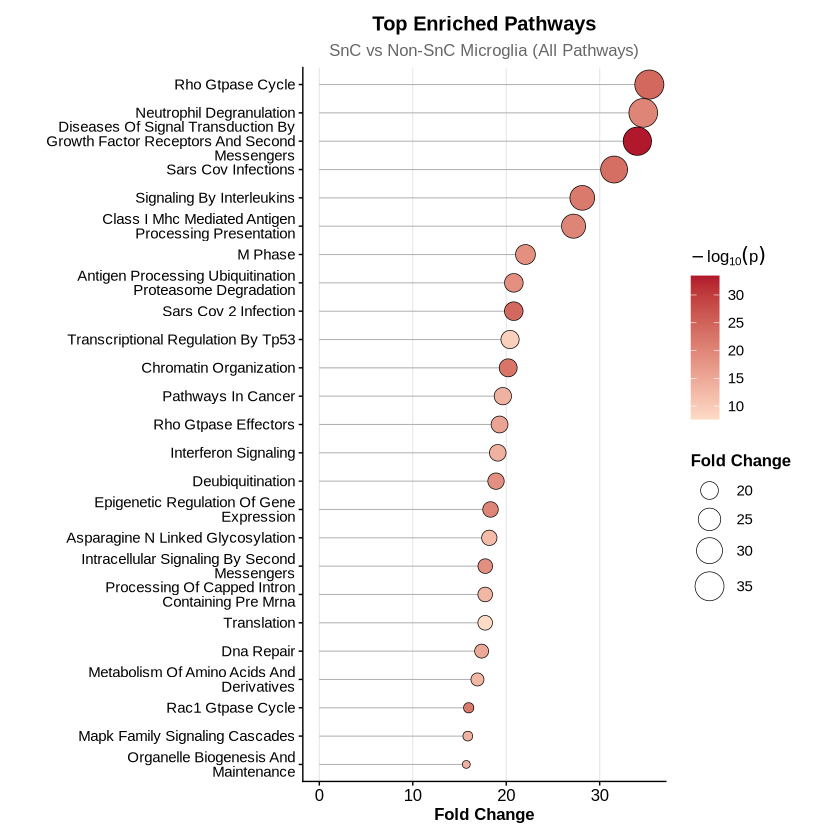

✓ Senescence pathways dot plot saved

------------------------------------------------------------
COMPARISON
------------------------------------------------------------
Top 25 overall pathways: 25 
Top 25 senescence pathways: 25 
Overlap: 1 

Senescence pathways in top overall:
  - Transcriptional Regulation By Tp53 

Senescence-related in top 25 overall: 1 (4%)

------------------------------------------------------------
INTERPRETATION
------------------------------------------------------------
If senescence pathways dominate the top overall list,
it validates that SnC classification captures true
senescence biology as the primary signal.
------------------------------------------------------------


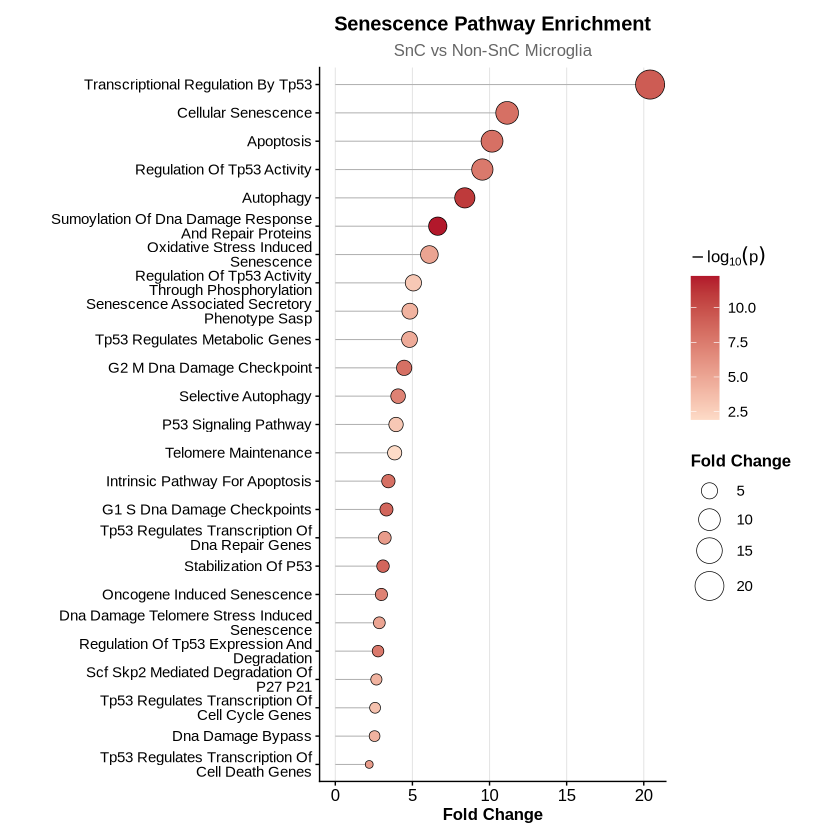

In [4]:
# %% Cell 8d: Dot Plots - Top Pathways & Senescence Pathways
# ============================================================

library(ggplot2)
library(dplyr)
library(stringr)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATASET <- 'psychad_aging'
BASE_DIR <- '/fs/scratch/PAS2598/senescence_analysis'
RESULTS_DIR <- file.path(BASE_DIR, 'results', '06_pathway_enrichment', DATASET)
FIGURES_DIR <- file.path(BASE_DIR, 'figures', '06_pathway_enrichment', DATASET)

# ------------------------------------------------------------
# Text wrap function
# ------------------------------------------------------------

wrap_text <- function(x, width = 40) {
  sapply(x, function(y) paste(strwrap(y, width = width), collapse = "\n"))
}

# Clean pathway names (remove prefixes, underscores)
clean_pathway_name <- function(x) {
  x <- gsub("^HALLMARK_|^KEGG_|^REACTOME_|^GOBP_|^WP_|^BIOCARTA_", "", x)
  x <- gsub("_", " ", x)
  x <- str_to_title(x)
  return(x)
}

# ------------------------------------------------------------
# Publication theme
# ------------------------------------------------------------

theme_pub <- function(base_size = 10) {
  theme_classic(base_size = base_size) +
    theme(
      plot.title = element_text(size = base_size + 2, face = "bold", hjust = 0.5),
      plot.subtitle = element_text(size = base_size, hjust = 0.5, color = "gray40"),
      axis.title = element_text(size = base_size, face = "bold"),
      axis.text = element_text(size = base_size, color = "black"),
      axis.text.y = element_text(size = base_size - 1, lineheight = 0.8),
      axis.line = element_line(linewidth = 0.4),
      axis.ticks = element_line(linewidth = 0.4),
      legend.title = element_text(size = base_size, face = "bold"),
      legend.text = element_text(size = base_size - 1),
      legend.position = "right",
      panel.grid.major.x = element_line(color = "grey90", linewidth = 0.3),
      panel.grid.minor = element_blank(),
      plot.margin = margin(10, 15, 10, 10)
    )
}

# ------------------------------------------------------------
# Helper function for dot plot
# ------------------------------------------------------------

make_dotplot <- function(data, title, subtitle, top_n = 25, fc_threshold = 2, wrap_width = 35) {
  
  plot_data <- data %>%
    filter(adjPval < 0.05, FC >= fc_threshold) %>%
    arrange(desc(FC)) %>%
    mutate(
      neg_log_p = -log10(adjPval),
      Pathway_clean = clean_pathway_name(Pathway),
      Pathway_wrap = wrap_text(Pathway_clean, width = wrap_width)
    ) %>%
    # Remove duplicates AFTER cleaning (keep highest FC)
    distinct(Pathway_wrap, .keep_all = TRUE) %>%
    slice_head(n = top_n)
  
  # Set factor levels using unique values
  plot_data$Pathway_wrap <- factor(plot_data$Pathway_wrap, 
                                    levels = rev(unique(plot_data$Pathway_wrap)))
  
  cat("Plotting", nrow(plot_data), "pathways\n")
  
  p <- ggplot(plot_data, aes(x = FC, y = Pathway_wrap)) +
    geom_segment(aes(x = 0, xend = FC, y = Pathway_wrap, yend = Pathway_wrap),
                 color = "grey70", linewidth = 0.3) +
    geom_point(aes(size = FC, fill = neg_log_p), 
               shape = 21, color = "black", stroke = 0.3) +
    scale_fill_gradient(
      low = "#FDDBC7",
      high = "#B2182B",
      name = expression(-log[10](p))
    ) +
    scale_size_continuous(
      range = c(2, 8),
      name = "Fold Change"
    ) +
    labs(
      title = title,
      subtitle = subtitle,
      x = "Fold Change",
      y = NULL
    ) +
    theme_pub() +
    guides(
      fill = guide_colorbar(order = 1),
      size = guide_legend(order = 2)
    )
  
  return(list(plot = p, data = plot_data))
}

# ============================================================
# PLOT 1: TOP PATHWAYS (ALL)
# ============================================================

cat("------------------------------------------------------------\n")
cat("PLOT 1: TOP PATHWAYS (ALL)\n")
cat("------------------------------------------------------------\n")

# Load all results
all_results <- read.csv(file.path(RESULTS_DIR, paste0(DATASET, "_scpa_snc_vs_nonsnc_all.csv")))

# Filter to Microglia
all_microglia <- all_results %>%
  filter(cell_type == "Microglia")

cat("Total pathways tested:", nrow(all_microglia), "\n")

# Create dot plot
result1 <- make_dotplot(
  data = all_microglia,
  title = "Top Enriched Pathways",
  subtitle = "SnC vs Non-SnC Microglia (All Pathways)",
  top_n = 25,
  fc_threshold = 2,
  wrap_width = 35
)

print(result1$plot)

# Save
fig_height1 <- max(6, nrow(result1$data) * 0.35 + 2)
ggsave(file.path(FIGURES_DIR, paste0(DATASET, "_scpa_microglia_top_pathways_dotplot.pdf")),
       result1$plot, width = 7, height = fig_height1, dpi = 300)
ggsave(file.path(FIGURES_DIR, paste0(DATASET, "_scpa_microglia_top_pathways_dotplot.png")),
       result1$plot, width = 7, height = fig_height1, dpi = 300)

cat("✓ Top pathways dot plot saved\n\n")

# ============================================================
# PLOT 2: TOP SENESCENCE PATHWAYS
# ============================================================

cat("------------------------------------------------------------\n")
cat("PLOT 2: TOP SENESCENCE PATHWAYS\n")
cat("------------------------------------------------------------\n")

# Filter to senescence-related pathways
senescence_pattern <- "SENESC|AGING|P53|P21|P16|TELOMERE|DNA_DAMAGE|OXIDATIVE_STRESS|APOPTOSIS|AUTOPHAGY|SASP"

sen_microglia <- all_microglia %>%
  filter(grepl(senescence_pattern, Pathway, ignore.case = TRUE))

cat("Senescence-related pathways:", nrow(sen_microglia), "\n")

# Create dot plot
result2 <- make_dotplot(
  data = sen_microglia,
  title = "Senescence Pathway Enrichment",
  subtitle = "SnC vs Non-SnC Microglia",
  top_n = 25,
  fc_threshold = 2,
  wrap_width = 35
)

print(result2$plot)

# Save
fig_height2 <- max(6, nrow(result2$data) * 0.35 + 2)
ggsave(file.path(FIGURES_DIR, paste0(DATASET, "_scpa_microglia_senescence_dotplot.pdf")),
       result2$plot, width = 7, height = fig_height2, dpi = 300)
ggsave(file.path(FIGURES_DIR, paste0(DATASET, "_scpa_microglia_senescence_dotplot.png")),
       result2$plot, width = 7, height = fig_height2, dpi = 300)

cat("✓ Senescence pathways dot plot saved\n\n")

# ============================================================
# COMPARISON: Are senescence pathways in top overall?
# ============================================================

cat("------------------------------------------------------------\n")
cat("COMPARISON\n")
cat("------------------------------------------------------------\n")

top_all <- result1$data$Pathway
top_sen <- result2$data$Pathway

# Check overlap
overlap <- intersect(as.character(top_all), as.character(top_sen))

cat("Top 25 overall pathways:", length(top_all), "\n")
cat("Top 25 senescence pathways:", length(top_sen), "\n")
cat("Overlap:", length(overlap), "\n")

if (length(overlap) > 0) {
  cat("\nSenescence pathways in top overall:\n")
  for (p in overlap) {
    cat("  -", clean_pathway_name(p), "\n")
  }
}

# What % of top pathways are senescence-related?
n_sen_in_top <- sum(grepl(senescence_pattern, top_all, ignore.case = TRUE))
cat("\nSenescence-related in top 25 overall:", n_sen_in_top, 
    sprintf("(%.0f%%)\n", 100 * n_sen_in_top / length(top_all)))

cat("\n------------------------------------------------------------\n")
cat("INTERPRETATION\n")
cat("------------------------------------------------------------\n")
cat("If senescence pathways dominate the top overall list,\n")
cat("it validates that SnC classification captures true\n")
cat("senescence biology as the primary signal.\n")
cat("------------------------------------------------------------\n")

In [5]:
# %% Cell 9: Module 06b Summary
# ============================================================

DATASET <- 'psychad_aging'
BASE_DIR <- '/fs/scratch/PAS2598/senescence_analysis'
RESULTS_DIR <- file.path(BASE_DIR, 'results', '06_pathway_enrichment', DATASET)
FIGURES_DIR <- file.path(BASE_DIR, 'figures', '06_pathway_enrichment', DATASET)
CELL_TYPES <- c('Microglia')

cat("============================================================\n")
cat("MODULE 06b: SCPA PATHWAY ANALYSIS - COMPLETE\n")
cat("============================================================\n")
cat("Dataset:", DATASET, "\n")
cat("Comparison: SnC vs Non-SnC\n")
cat("Cell type:", paste(CELL_TYPES, collapse = ", "), "\n")

cat("\n------------------------------------------------------------\n")
cat("KEY FINDINGS\n")
cat("------------------------------------------------------------\n")
cat("1. Senescence pathways significantly enriched in SnC microglia\n")
cat("2. Strong FC values indicate robust senescence signature\n")
cat("3. Top pathways: TP53 regulation, Autophagy, Cellular Senescence\n")
cat("4. Validates SenePy classification captures true senescence biology\n")

cat("\n------------------------------------------------------------\n")
cat("FILES GENERATED\n")
cat("------------------------------------------------------------\n")

cat("\nResults:\n")
result_files <- list.files(RESULTS_DIR, pattern = "scpa")
for (f in result_files) {
  cat("  -", f, "\n")
}

cat("\nFigures:\n")
figure_files <- list.files(FIGURES_DIR, pattern = "scpa")
for (f in figure_files) {
  cat("  -", f, "\n")
}

cat("\n------------------------------------------------------------\n")
cat("INTERPRETATION\n")
cat("------------------------------------------------------------\n")
cat("SCPA confirms SenePy-classified SnC microglia show coordinated\n")
cat("upregulation of senescence pathways. This provides orthogonal\n")
cat("validation that SnC classification captures true senescence\n")
cat("biology, not just random gene expression differences.\n")

cat("\n============================================================\n")
cat("MODULE 06b COMPLETE\n")
cat("============================================================\n")

MODULE 06b: SCPA PATHWAY ANALYSIS - COMPLETE
Dataset: psychad_aging 
Comparison: SnC vs Non-SnC
Cell type: Microglia 

------------------------------------------------------------
KEY FINDINGS
------------------------------------------------------------
1. Senescence pathways significantly enriched in SnC microglia
2. Strong FC values indicate robust senescence signature
3. Top pathways: TP53 regulation, Autophagy, Cellular Senescence
4. Validates SenePy classification captures true senescence biology

------------------------------------------------------------
FILES GENERATED
------------------------------------------------------------

Results:
  - psychad_aging_scpa_all_significant_wide.csv 
  - psychad_aging_scpa_microglia_pathway_summary.csv 
  - psychad_aging_scpa_senescence_pathways_wide.csv 
  - psychad_aging_scpa_senescence_pathways.csv 
  - psychad_aging_scpa_snc_vs_nonsnc_all.csv 
  - psychad_aging_scpa_snc_vs_nonsnc_astrocyte.csv 
  - psychad_aging_scpa_snc_vs_nonsnc_micro

In [1]:
# ════════════════════════════════════════════════════════════════════════════════
# SANKEY DIAGRAM - SCPA RESULTS (MICROGLIA ONLY)
# ════════════════════════════════════════════════════════════════════════════════
# Flow: Pathway → Category
# Link thickness = Fold Change
# ════════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("SANKEY DIAGRAM - SCPA RESULTS (MICROGLIA)")
print("=" * 60)

# ─────────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import re
warnings.filterwarnings('ignore')

print("\n✓ Core packages loaded")

# Check Plotly
try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
    print("✓ Plotly loaded")
except ImportError:
    PLOTLY_AVAILABLE = False
    print("✗ Plotly not available - install with: pip install plotly")

# Check Kaleido (for static export)
try:
    import kaleido
    KALEIDO_AVAILABLE = True
    print("✓ Kaleido loaded (PDF/PNG export available)")
except ImportError:
    KALEIDO_AVAILABLE = False
    print("⚠ Kaleido not available - install with: pip install -U kaleido")

# ─────────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────────

print("\n" + "-" * 60)
print("CONFIGURATION")
print("-" * 60)

# Dataset
DATASET = 'psychad_aging'
CELL_TYPE = 'Microglia'

# Paths
BASE_DIR = Path('/fs/scratch/PAS2598/senescence_analysis')
RESULTS_DIR = BASE_DIR / 'results' / '06_pathway_enrichment' / DATASET
FIGURES_DIR = BASE_DIR / 'figures' / '06_pathway_enrichment' / DATASET

# Create output directory
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Input file
SCPA_FILE = RESULTS_DIR / f"{DATASET}_scpa_snc_vs_nonsnc_all.csv"

# Thresholds
FDR_THRESHOLD = 0.05
FC_THRESHOLD = 2
TOP_N_PATHWAYS = 50

# Text settings
WRAP_WIDTH = 30

print(f"  Dataset: {DATASET}")
print(f"  Cell type: {CELL_TYPE}")
print(f"  Input: {SCPA_FILE.name}")
print(f"  Figures: {FIGURES_DIR}")
print(f"  FDR threshold: {FDR_THRESHOLD}")
print(f"  FC threshold: {FC_THRESHOLD}")
print(f"  Top N pathways: {TOP_N_PATHWAYS}")
print(f"  Text wrap width: {WRAP_WIDTH}")

# ─────────────────────────────────────────────────────────────────────────────────
# COLOR PALETTES
# ─────────────────────────────────────────────────────────────────────────────────

# Category colors
CATEGORY_COLORS = {
    'TP53 Signaling': '#E63946',
    'Apoptosis': '#F4A261',
    'Cell Cycle': '#2A9D8F',
    'Senescence': '#E76F51',
    'Autophagy': '#264653',
    'DNA Damage': '#A8DADC',
    'Protein Modification': '#457B9D',
    'Metabolism': '#8AB17D',
    'Inflammation': '#D62828',
    'Oxidative Stress': '#FCBF49',
    'Signal Transduction': '#9B59B6',
    'Immune Response': '#3498DB',
    'Cell Death': '#E74C3C',
    'Transcription': '#1ABC9C',
    'Other': '#999999',
}

# Category display order (Other always last)
CATEGORY_ORDER = [
    'TP53 Signaling',
    'Senescence',
    'Cell Cycle',
    'DNA Damage',
    'Apoptosis',
    'Cell Death',
    'Autophagy',
    'Inflammation',
    'Immune Response',
    'Signal Transduction',
    'Transcription',
    'Metabolism',
    'Protein Modification',
    'Oxidative Stress',
    'Other',
]

# Category keywords for pathway classification
CATEGORY_KEYWORDS = {
    'TP53 Signaling': ['tp53', 'p53'],
    'Apoptosis': ['apoptosis', 'apoptotic'],
    'Cell Cycle': ['cell cycle', 'g1', 'g2', 'mitotic', 'cyclin', 'spindle', 'cohesin', 'm phase'],
    'Senescence': ['senescence', 'sahf', 'sasp'],
    'Autophagy': ['autophagy', 'lysosom'],
    'DNA Damage': ['dna damage', 'dna repair', 'telomere', 'chk1', 'chk2'],
    'Protein Modification': ['sumo', 'ubiquitin', 'antigen processing'],
    'Metabolism': ['metabol', 'biosynthesis', 'biogenesis'],
    'Inflammation': ['inflamm', 'interleukin', 'cytokine', 'nfkb', 'neutrophil'],
    'Oxidative Stress': ['oxidative', 'ros', 'stress'],
    'Signal Transduction': ['signal transduction', 'fgfr', 'wnt', 'rho', 'gtpase', 'receptor', 'mapk', 'signaling', 'second mes'],
    'Immune Response': ['immune', 'infection', 'sars', 'viral', 'mhc', 'antigen'],
    'Cell Death': ['death', 'necrosis'],
    'Transcription': ['transcription', 'gene expression'],
}

# Abbreviations for common words
ABBREVIATIONS = {
    'Regulation': 'Reg.',
    'Signaling': 'Signal.',
    'Transduction': 'Transd.',
    'Processing': 'Process.',
    'Mediated': 'Med.',
    'Dependent': 'Dep.',
    'Independent': 'Indep.',
    'Activation': 'Activ.',
    'Inactivation': 'Inactiv.',
    'Transcription': 'Txn',
    'Transcriptional': 'Txnal',
    'Expression': 'Expr.',
    'Metabolism': 'Metab.',
    'Biosynthesis': 'Biosynth.',
    'Degradation': 'Degrad.',
    'Modification': 'Modif.',
    'Organization': 'Org.',
    'Maintenance': 'Maint.',
    'Assembly': 'Assemb.',
    'Disassembly': 'Disassemb.',
    'Replication': 'Replic.',
    'Checkpoint': 'Chkpt',
    'Response': 'Resp.',
    'Infection': 'Infect.',
    'Diseases': 'Dis.',
    'Disease': 'Dis.',
    'Intracellular': 'Intracell.',
    'Extracellular': 'Extracell.',
    'Ubiquitination': 'Ubiq.',
    'Phosphorylation': 'Phosph.',
    'Dephosphorylation': 'Dephosph.',
    'Through': 'Thru',
    'Protein': 'Prot.',
    'Proteins': 'Prots.',
    'Receptor': 'Recept.',
    'Receptors': 'Recepts.',
    'Factor': 'Fact.',
    'Factors': 'Facts.',
    'Pathway': 'Path.',
    'Pathways': 'Paths.',
    'Complex': 'Cplx',
    'Development': 'Dev.',
    'Developmental': 'Devel.',
    'Formation': 'Form.',
    'Differentiation': 'Diff.',
    'Proliferation': 'Prolif.',
    'Communication': 'Comm.',
    'Interaction': 'Interact.',
    'Interactions': 'Interacts.',
    'Associated': 'Assoc.',
    'Including': 'Incl.',
    'Involved': 'Invol.',
    'Required': 'Req.',
    'Containing': 'Contain.',
    'Membrane': 'Membr.',
    'Mitochondrial': 'Mito.',
    'Cytoplasmic': 'Cyto.',
    'Nuclear': 'Nucl.',
    'Chromosome': 'Chrom.',
    'Chromosomal': 'Chrom.',
}

print(f"\n✓ Color palettes configured")
print(f"✓ {len(ABBREVIATIONS)} abbreviations defined")

# ─────────────────────────────────────────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────────

def apply_abbreviations(text, abbrev_dict):
    """Apply abbreviations to text."""
    for full, abbr in abbrev_dict.items():
        pattern = r'\b' + re.escape(full) + r'\b'
        text = re.sub(pattern, abbr, text, flags=re.IGNORECASE)
    return text

def wrap_text(text, width=30):
    """Wrap text at specified width using <br> tags."""
    words = text.split()
    lines = []
    current_line = []
    current_length = 0
    
    for word in words:
        word_length = len(word)
        if current_length + word_length + (1 if current_line else 0) <= width:
            current_line.append(word)
            current_length += word_length + (1 if len(current_line) > 1 else 0)
        else:
            if current_line:
                lines.append(' '.join(current_line))
            current_line = [word]
            current_length = word_length
    
    if current_line:
        lines.append(' '.join(current_line))
    
    return '<br>'.join(lines)

def clean_pathway_name(pathway, abbrev_dict, wrap_width):
    """Clean pathway name: remove prefixes, apply abbreviations, wrap text."""
    name = pathway.replace('REACTOME_', '').replace('KEGG_', '').replace('KEGG_MEDICUS_REFERENCE_', '')
    name = name.replace('_', ' ')
    name = name.title()
    name = apply_abbreviations(name, abbrev_dict)
    name = wrap_text(name, wrap_width)
    return name

def assign_category(pathway, keywords_dict):
    """Assign biological category based on pathway name."""
    p = pathway.lower()
    for category, keywords in keywords_dict.items():
        if any(kw in p for kw in keywords):
            return category
    return 'Other'

def hex_to_rgba(hex_color, alpha=0.5):
    """Convert hex color to rgba string."""
    if hex_color.startswith('#'):
        r = int(hex_color[1:3], 16)
        g = int(hex_color[3:5], 16)
        b = int(hex_color[5:7], 16)
        return f'rgba({r}, {g}, {b}, {alpha})'
    return f'rgba(150, 150, 150, {alpha})'

def sort_categories(cat_list, order_list):
    """Sort categories according to predefined order, with 'Other' always last."""
    def get_order(cat):
        if cat in order_list:
            return order_list.index(cat)
        elif cat == 'Other':
            return 999
        else:
            return len(order_list) - 1
    return sorted(cat_list, key=get_order)

print("✓ Helper functions defined")

# ─────────────────────────────────────────────────────────────────────────────────
# CREATE SANKEY DIAGRAM
# ─────────────────────────────────────────────────────────────────────────────────

print("\n" + "-" * 60)
print("CREATING SANKEY DIAGRAM")
print("-" * 60)

if PLOTLY_AVAILABLE:
    
    if not SCPA_FILE.exists():
        print(f"\n✗ File not found: {SCPA_FILE}")
    else:
        # Load SCPA results
        df = pd.read_csv(SCPA_FILE)
        
        print(f"\n✓ Loaded: {SCPA_FILE.name}")
        print(f"  Total rows: {len(df)}")
        print(f"  Cell types available: {df['cell_type'].unique().tolist()}")
        
        # Filter to Microglia only
        df = df[df['cell_type'] == CELL_TYPE].copy()
        print(f"  {CELL_TYPE} rows: {len(df)}")
        
        # Filter significant
        df_sig = df[(df['adjPval'] < FDR_THRESHOLD) & (df['FC'] >= FC_THRESHOLD)].copy()
        print(f"  Significant (FDR < {FDR_THRESHOLD}, FC >= {FC_THRESHOLD}): {len(df_sig)}")
        
        if len(df_sig) == 0:
            print("\n⚠ No significant pathways found. Try adjusting thresholds.")
        else:
            # Get top N pathways by FC
            df_top = df_sig.nlargest(TOP_N_PATHWAYS, 'FC').reset_index(drop=True)
            print(f"  Top {TOP_N_PATHWAYS} pathways: {len(df_top)}")
            
            # Assign categories
            df_top['Category'] = df_top['Pathway'].apply(
                lambda x: assign_category(x, CATEGORY_KEYWORDS)
            )
            
            # Clean pathway names for display
            df_top['Pathway_Clean'] = df_top['Pathway'].apply(
                lambda x: clean_pathway_name(x, ABBREVIATIONS, WRAP_WIDTH)
            )
            
            # Show example transformations
            print(f"\nExample pathway name transformations:")
            for i, row in df_top.head(3).iterrows():
                orig = row['Pathway'][:50] + '...' if len(row['Pathway']) > 50 else row['Pathway']
                clean = row['Pathway_Clean'].replace('<br>', ' | ')
                print(f"  {orig}")
                print(f"    → {clean}")
            
            print(f"\nCategories assigned:")
            for cat, count in df_top['Category'].value_counts().items():
                print(f"  {cat}: {count}")
            
            # ─────────────────────────────────────────────────────────────────
            # Build Sankey nodes: Pathway → Category
            # ─────────────────────────────────────────────────────────────────
            
            # Get pathway to category mapping
            pathway_to_category = df_top.set_index('Pathway_Clean')['Category'].to_dict()
            
            pathways = df_top['Pathway_Clean'].unique().tolist()
            
            # Sort categories according to predefined order
            categories_raw = df_top['Category'].unique().tolist()
            categories = sort_categories(categories_raw, CATEGORY_ORDER)
            
            # Node order: Pathways → Categories
            node_labels = pathways + categories
            node_idx = {name: i for i, name in enumerate(node_labels)}
            
            print(f"\nSankey structure:")
            print(f"  Pathways (left): {len(pathways)}")
            print(f"  Categories (right): {categories}")
            
            # ─────────────────────────────────────────────────────────────────
            # Calculate flow weights for positioning
            # ─────────────────────────────────────────────────────────────────
            
            # Calculate total flow per category (for proportional positioning)
            cat_flow = df_top.groupby('Category')['FC'].sum().to_dict()
            
            # Calculate total flow per pathway
            pathway_flow = df_top.set_index('Pathway_Clean')['FC'].to_dict()
            
            print(f"\nFlow weights by category:")
            for cat in categories:
                print(f"  {cat}: {cat_flow.get(cat, 0):.1f}")
            
            # ─────────────────────────────────────────────────────────────────
            # Calculate node positions based on flow
            # ─────────────────────────────────────────────────────────────────
            
            node_x = []
            node_y = []
            
            # --- Pathways (left column) ---
            # Sort pathways by their category, then by FC within category
            pathway_cat_list = [(p, pathway_to_category.get(p, 'Other')) for p in pathways]
            pathway_cat_list.sort(key=lambda x: (
                CATEGORY_ORDER.index(x[1]) if x[1] in CATEGORY_ORDER else 999,
                -pathway_flow.get(x[0], 0)
            ))
            pathways_sorted = [p[0] for p in pathway_cat_list]
            
            # Recalculate node labels with sorted pathways
            pathways = pathways_sorted
            node_labels = pathways + categories
            node_idx = {name: i for i, name in enumerate(node_labels)}
            
            n_pathways = len(pathways)
            path_padding = 0.02
            path_range = 1 - (2 * path_padding)
            for i in range(n_pathways):
                node_x.append(0.20)
                node_y.append(path_padding + (i + 0.5) * path_range / n_pathways)
            
            # --- Categories (right column) - flow-weighted positioning ---
            n_categories = len(categories)
            total_cat_flow = sum(cat_flow.get(c, 1) for c in categories)
            
            cat_padding = 0.05
            cat_range = 1 - (2 * cat_padding)
            
            # Calculate cumulative positions based on flow
            cumulative = cat_padding
            cat_positions = []
            for cat in categories:
                flow = cat_flow.get(cat, 1)
                height = (flow / total_cat_flow) * cat_range
                pos = cumulative + height / 2
                cat_positions.append(pos)
                cumulative += height
            
            for i, cat in enumerate(categories):
                node_x.append(0.80)
                node_y.append(cat_positions[i])
            
            # ─────────────────────────────────────────────────────────────────
            # Build Sankey links (FC-weighted)
            # ─────────────────────────────────────────────────────────────────
            
            sources, targets, values, link_colors = [], [], [], []
            
            # Pathway → Category links
            for _, row in df_top.iterrows():
                sources.append(node_idx[row['Pathway_Clean']])
                targets.append(node_idx[row['Category']])
                values.append(row['FC'])
                cat_color = CATEGORY_COLORS.get(row['Category'], '#999999')
                link_colors.append(hex_to_rgba(cat_color, 0.5))
            
            print(f"  Total links: {len(sources)}")
            
            # ─────────────────────────────────────────────────────────────────
            # Node colors - Pathways colored by their category
            # ─────────────────────────────────────────────────────────────────
            
            node_colors = []
            for name in node_labels:
                if name in pathways:
                    cat = pathway_to_category.get(name, 'Other')
                    cat_color = CATEGORY_COLORS.get(cat, '#999999')
                    node_colors.append(hex_to_rgba(cat_color, 0.8))
                elif name in CATEGORY_COLORS:
                    node_colors.append(hex_to_rgba(CATEGORY_COLORS[name], 0.9))
                else:
                    node_colors.append('rgba(150, 150, 150, 0.8)')
            
            # ─────────────────────────────────────────────────────────────────
            # Create Sankey figure
            # ─────────────────────────────────────────────────────────────────
            
            fig = go.Figure(data=[go.Sankey(
                arrangement='fixed',
                node=dict(
                    pad=25,
                    thickness=20,
                    line=dict(color='white', width=0.5),
                    label=node_labels,
                    color=node_colors,
                    x=node_x,
                    y=node_y
                ),
                link=dict(
                    source=sources,
                    target=targets,
                    value=values,
                    color=link_colors
                )
            )])
            
            fig.update_layout(
                title=dict(
                    text=f'{DATASET}: {CELL_TYPE} Pathway Enrichment (SnC vs Non-SnC)<br>'
                         f'<sub>Top {TOP_N_PATHWAYS} pathways | FC ≥ {FC_THRESHOLD}, FDR < {FDR_THRESHOLD}</sub>',
                    font=dict(size=14),
                    x=0.5,
                    xanchor='center'
                ),
                font=dict(size=10),
                height=900,
                width=1200,
                paper_bgcolor='white',
                plot_bgcolor='white',
                margin=dict(t=80, l=300, r=150, b=40)
            )
            
            # ─────────────────────────────────────────────────────────────────
            # Legend
            # ─────────────────────────────────────────────────────────────────
            
            # Categories legend (right side)
            legend_cat = '<b>Categories</b><br>' + '<br>'.join(
                [f'<span style="color:{CATEGORY_COLORS.get(cat, "#999")}">●</span> {cat}' 
                 for cat in categories]
            )
            fig.add_annotation(
                x=0.99, y=0.99,
                xref='paper', yref='paper',
                xanchor='right', yanchor='top',
                text=legend_cat,
                showarrow=False,
                font=dict(size=9),
                bgcolor='rgba(255,255,255,0.95)',
                bordercolor='#ccc',
                borderwidth=1,
                borderpad=8
            )
            
            # Flow explanation (top left)
            fig.add_annotation(
                x=0.01, y=0.99,
                xref='paper', yref='paper',
                xanchor='left', yanchor='top',
                text=f'<b>{CELL_TYPE}</b><br><br>'
                     '<b>Flow</b><br>'
                     'Pathway → Category<br><br>'
                     '<b>Link thickness</b><br>'
                     'Fold Change',
                showarrow=False,
                font=dict(size=9),
                bgcolor='rgba(255,255,255,0.95)',
                bordercolor='#ccc',
                borderwidth=1,
                borderpad=8
            )
            
            # ─────────────────────────────────────────────────────────────────
            # Save outputs
            # ─────────────────────────────────────────────────────────────────
            
            print("\n" + "-" * 60)
            print("SAVING OUTPUTS")
            print("-" * 60)
            
            # HTML (interactive)
            sankey_html = FIGURES_DIR / f'{DATASET}_scpa_sankey_microglia.html'
            fig.write_html(sankey_html)
            print(f"✓ Saved: {sankey_html.name}")
            
            # PDF/PNG (static)
            if KALEIDO_AVAILABLE:
                sankey_pdf = FIGURES_DIR / f'{DATASET}_scpa_sankey_microglia.pdf'
                sankey_png = FIGURES_DIR / f'{DATASET}_scpa_sankey_microglia.png'
                
                fig.write_image(sankey_pdf, scale=2)
                print(f"✓ Saved: {sankey_pdf.name}")
                
                fig.write_image(sankey_png, scale=2)
                print(f"✓ Saved: {sankey_png.name}")
            else:
                print("⚠ Skipping PDF/PNG - install kaleido: pip install -U kaleido")
            
            # Display
            fig.show()
            
            print("\n✓ Sankey diagram complete")

else:
    print("\n✗ Skipping - Plotly not available")
    print("  Install with: pip install plotly")

print("\n" + "=" * 60)

SANKEY DIAGRAM - SCPA RESULTS (MICROGLIA)

✓ Core packages loaded
✓ Plotly loaded
✓ Kaleido loaded (PDF/PNG export available)

------------------------------------------------------------
CONFIGURATION
------------------------------------------------------------
  Dataset: psychad_aging
  Cell type: Microglia
  Input: psychad_aging_scpa_snc_vs_nonsnc_all.csv
  Figures: /fs/scratch/PAS2598/senescence_analysis/figures/06_pathway_enrichment/psychad_aging
  FDR threshold: 0.05
  FC threshold: 2
  Top N pathways: 50
  Text wrap width: 30

✓ Color palettes configured
✓ 60 abbreviations defined
✓ Helper functions defined

------------------------------------------------------------
CREATING SANKEY DIAGRAM
------------------------------------------------------------

✓ Loaded: psychad_aging_scpa_snc_vs_nonsnc_all.csv
  Total rows: 1493
  Cell types available: ['Microglia']
  Microglia rows: 1493
  Significant (FDR < 0.05, FC >= 2): 722
  Top 50 pathways: 50

Example pathway name transformation


✓ Sankey diagram complete

